In [30]:
from ase import Atoms
from xtb.ase.calculator import XTB
# Import read from ase 
from ase.io import read
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# for visualization in notebook
from ase.visualize import view
import seaborn as sns


# DScribe Testing

The goal of this notebook is to provide the arguments for which kind of descriptor i want to use in my final project.

DScribe has the following descriptors:

+ Coloumb Matrix
+ Sine Matrix
+ Ewald Sum Matrix
+ Atom-centered symmetry functions
+ Smooth Overlap of Atomic Positions (SOAP)
+ Many-body Tensor Representation (MBTR)
+ Local Many-body Tensor Representation (LMBTR)
+ Valle-Oganov Descriptor

As a test-molecule throughout this notebook i will use $CO_2$ which is also great for testing perumtational invariance of the descriptors. First we use **ase** to create the molecule

In [31]:
co2 = read("/media/storage_6/lme/master_thesis/cluster_generation/test_molecules/co2.xyz")
co2_stretch = co2.copy()
pos = co2_stretch.get_positions()
# Move first oxygen by 0.2 angstrom
pos[1,2] += 0.2
co2_stretch.set_positions(pos)

print(f"New bond length: {pos[1,2] - pos[0,2]:.2f} Å")
print(f"Original bond length: {co2.get_positions()[1,2] - co2.get_positions()[0,2]:.2f} Å")

co2_bent = co2.copy()

# We want to set the angle between indices 1, 0, and 2 
# Norm of v is zero error, so we need to move the first oxygen slightly
pos = co2_bent.get_positions()
pos[1,0] += 0.01
co2_bent.set_positions(pos)
co2_bent.set_angle(1, 0, 2, 120)
print(f"New angle: {co2_bent.get_angle(1, 0, 2):.2f} degrees")

# Make permutation of oxygens
co2_perm = co2.copy()
pos = co2_perm.get_positions()
# Swap positions of oxygens
pos[[1, 2]] = pos[[2, 1]]
co2_perm.set_positions(pos)
print(f"Original positions:\n{co2.get_positions()}")
print(f"Permuted positions:\n{co2_perm.get_positions()}")


New bond length: 1.36 Å
Original bond length: 1.16 Å
New angle: 120.00 degrees
Original positions:
[[ 0.          0.          0.        ]
 [ 0.          0.          1.16294107]
 [ 0.          0.         -1.16294107]]
Permuted positions:
[[ 0.          0.          0.        ]
 [ 0.          0.         -1.16294107]
 [ 0.          0.          1.16294107]]


In [32]:
view(co2, viewer="x3d")

In [33]:
view(co2_stretch, viewer="x3d")

In [34]:
view(co2_bent, viewer="x3d")

In [35]:
view(co2_perm, viewer="x3d")

# Coloumb Matrix

Is a simple global descriptor which mimics the electrostatic interaction between nuclei. Is calculated via

$$M_{i,j}^{Coloumb} = \begin{cases} 0.5 Z_i^{2.4} & \text{if } i = j \\ \frac{Z_i Z_j}{|R_i - R_j|} & \text{if } i \neq j \end{cases}$$

Where $Z_i$ is the atomic number of atom $i$ and $R_i$ is the position of atom $i$. The coloumb matrix is not invariant to permutations of the atoms, but it is invariant to rotations and translations. To make it invariant to permutations, we can sort the matrix by the norm of the rows.

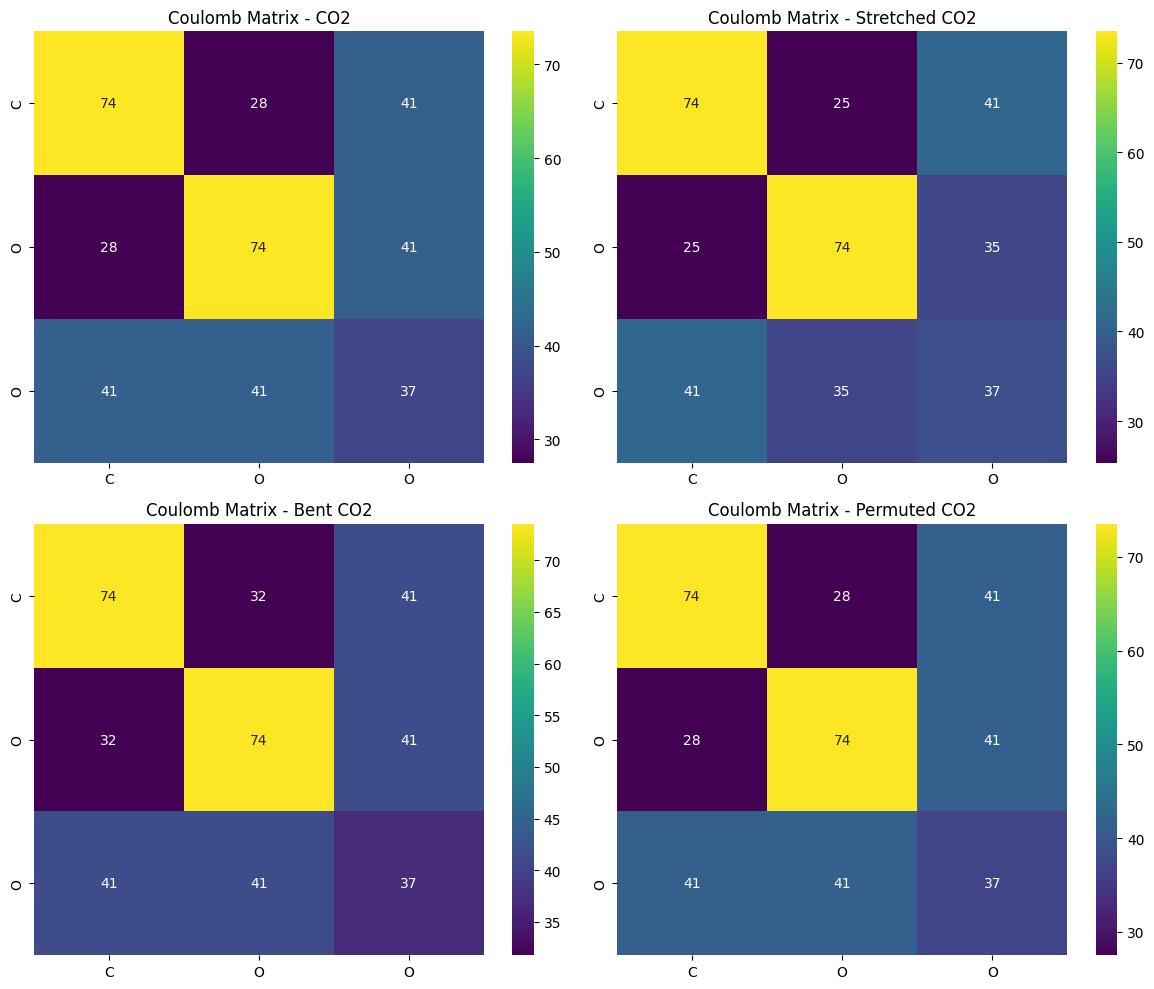

In [36]:
from dscribe.descriptors import CoulombMatrix

cm = CoulombMatrix(n_atoms_max=3)
cm_co2 = cm.create(co2)
cm_co2_stretch = cm.create(co2_stretch)
cm_co2_bent = cm.create(co2_bent)
cm_co2_perm = cm.create(co2_perm)
# Arrays are all flattened, so we need to reshape them to 3x3 matrices
cm_co2 = cm_co2.reshape(3, 3)
cm_co2_stretch = cm_co2_stretch.reshape(3, 3)
cm_co2_bent = cm_co2_bent.reshape(3, 3)
cm_co2_perm = cm_co2_perm.reshape(3, 3)

x_ticks = ["C", "O", "O"]
y_ticks = ["C", "O", "O"]

# Visualize the Columb matrices using Seaborn heatmap
import seaborn as sns
import matplotlib.pyplot as plt
fig, axs = plt.subplots(2, 2, figsize=(12, 10))
sns.heatmap(cm_co2, annot=True, cmap="viridis", ax=axs[0, 0], xticklabels=x_ticks, yticklabels=y_ticks)
axs[0, 0].set_title("Coulomb Matrix - CO2")
sns.heatmap(cm_co2_stretch, annot=True, cmap="viridis", ax=axs[0, 1], xticklabels=x_ticks, yticklabels=y_ticks)
axs[0, 1].set_title("Coulomb Matrix - Stretched CO2")
sns.heatmap(cm_co2_bent, annot=True, cmap="viridis", ax=axs[1, 0], xticklabels=x_ticks, yticklabels=y_ticks)
axs[1, 0].set_title("Coulomb Matrix - Bent CO2")
sns.heatmap(cm_co2_perm, annot=True, cmap="viridis", ax=axs[1, 1], xticklabels=x_ticks, yticklabels=y_ticks)
axs[1, 1].set_title("Coulomb Matrix - Permuted CO2")
plt.tight_layout()
plt.show()

Using the Eigenspectrum of the coloumb matrix or the sorted coloumb matrix according to the $L_2$ norm are two common ways to introduce permutational invariance to the coloumb matrix.

In [37]:
# Obtain the Coloumb Matrii Eigenspectrum and Compare
cm_eig = CoulombMatrix(n_atoms_max=3, permutation="eigenspectrum")
cm_eig_co2 = cm_eig.create(co2)
cm_eig_co2_stretch = cm_eig.create(co2_stretch)
cm_eig_co2_bent = cm_eig.create(co2_bent)
cm_eig_co2_perm = cm_eig.create(co2_perm)
print("Eigenspectrum of CO2:", cm_eig_co2)
print("Eigenspectrum of Stretched CO2:", cm_eig_co2_stretch)
print("Eigenspectrum of Bent CO2:", cm_eig_co2_bent)
print("Eigenspectrum of Permuted CO2:", cm_eig_co2_perm)

Eigenspectrum of CO2: [135.55496057  46.00025317   2.3362809 ]
Eigenspectrum of Stretched CO2: [130.25385263  48.44247803   5.19516397]
Eigenspectrum of Bent CO2: [138.73301448  41.74403218   3.41444798]
Eigenspectrum of Permuted CO2: [135.55496057  46.00025317   2.3362809 ]


## Atomic-centered symmetry functions

Cutoff function is


$$f_c(r) = \begin{cases} 0.5 \left[ \cos\left( \frac{\pi R_{ij}}{R_c} \right) + 1 \right] & R_{ij} \leq R_c \\ 0 & R_{ij} > R_c \end{cases}$$

+ Radial function are constructed as sums of two body terms
+ Angular functions additoonally contain three body terms.

Three radial symmetry functions are proposed:

+ $G_i^1 = \sum_{j} f_c (R_{ij})$
+ $G_i^2 = \sum_{j} e^{-\eta (R_{ij} - R_s)^2} f_c (R_{ij})$
+ $G_i^3 = \sum_{j} cos(\kappa R_{ij}) f_c (R_{ij})$



First we discuss the distinguishability using only the G1 function. 

In [38]:
from dscribe.descriptors import ACSF

# One has to give parameters of g2,g3,g4 and g5 functions to construct the ACSF descirptor, G1 is always added because it is a constant term.

acsf = ACSF(
    species=["C", "O"],
    r_cut=6.0,
)
acsf_co2 = acsf.create(co2)
acsf_co2_stretch = acsf.create(co2_stretch)
acsf_co2_bent = acsf.create(co2_bent)
acsf_co2_perm = acsf.create(co2_perm)

# Print dimensions of the descriptor, should be (n_atoms, n_features)
print(f"ACSF descriptor shape: {acsf_co2.shape}")

# Flatten the descriptors to 1D arrays for easier comparison
acsf_co2 = acsf_co2.flatten()
acsf_co2_stretch = acsf_co2_stretch.flatten()
acsf_co2_bent = acsf_co2_bent.flatten()
acsf_co2_perm = acsf_co2_perm.flatten()

# Compute Similarity Metrics we use the Euclidean Distance, Cosine Similarity, Manhatten distance
from scipy.spatial.distance import euclidean, cityblock
from scipy.spatial.distance import cosine

def compute_similarity_metrics(desc1, desc2):
    euclidean_dist = euclidean(desc1, desc2)
    cosine_sim =  cosine(desc1, desc2)  # Cosine similarity is 1 - cosine distance 
    manhattan_dist = cityblock(desc1, desc2)
    return euclidean_dist, cosine_sim, manhattan_dist

# Compare the original CO2 with the stretched, bent, and permuted versions
euc_stretch, cos_stretch, manh_stretch = compute_similarity_metrics(acsf_co2, acsf_co2_stretch)
euc_bent, cos_bent, manh_bent = compute_similarity_metrics(acsf_co2, acsf_co2_bent)
euc_perm, cos_perm, manh_perm = compute_similarity_metrics(acsf_co2, acsf_co2_perm)
# Print the results
print(f"Similarity Metrics (Original vs Stretched): Euclidean={euc_stretch:.4f}, Cosine Similarity={cos_stretch:.4f}, Manhattan={manh_stretch:.4f}")
print(f"Similarity Metrics (Original vs Bent): Euclidean={euc_bent:.4f}, Cosine Similarity={cos_bent:.4f}, Manhattan={manh_bent:.4f}")
print(f"Similarity Metrics (Original vs Permuted): Euclidean={euc_perm:.4f}, Cosine Similarity={cos_perm:.4f}, Manhattan={manh_perm:.4f}")  



ACSF descriptor shape: (3, 2)
Similarity Metrics (Original vs Stretched): Euclidean=0.0840, Cosine Similarity=0.0003, Manhattan=0.1643
Similarity Metrics (Original vs Bent): Euclidean=0.1045, Cosine Similarity=0.0008, Manhattan=0.1478
Similarity Metrics (Original vs Permuted): Euclidean=0.0000, Cosine Similarity=0.0000, Manhattan=0.0000


Now add the G2 functions and see how this similarity metrics change

In [39]:
acsf = ACSF(
    species=["C", "O"],
    r_cut=6.0,
    g2_params=[[1, 1], [2, 1], [3, 1]]
)
acsf_co2_g2 = acsf.create(co2)
acsf_co2_stretch_g2 = acsf.create(co2_stretch)
acsf_co2_bent_g2 = acsf.create(co2_bent)
acsf_co2_perm_g2 = acsf.create(co2_perm)

# Print dimensions of the G2 enhanced descriptor, should be (n_atoms, n_features)
print(f"G2 Enhanced ACSF descriptor shape: {acsf_co2_g2.shape}")    
# Flatten
acsf_co2_g2 = acsf_co2_g2.flatten()
acsf_co2_stretch_g2 = acsf_co2_stretch_g2.flatten()
acsf_co2_bent_g2 = acsf_co2_bent_g2.flatten()
acsf_co2_perm_g2 = acsf_co2_perm_g2.flatten()   


# Compute Similarity Metrics for the G2 enhanced descriptors
euc_stretch_g2, cos_stretch_g2, manh_stretch_g2 = compute_similarity_metrics(acsf_co2_g2, acsf_co2_stretch_g2)
euc_bent_g2, cos_bent_g2, manh_bent_g2 = compute_similarity_metrics(acsf_co2_g2, acsf_co2_bent_g2)  
euc_perm_g2, cos_perm_g2, manh_perm_g2 = compute_similarity_metrics(acsf_co2_g2, acsf_co2_perm_g2)
# Print the results for G2 enhanced descriptors
print(f"G2 Enhanced Similarity Metrics (Original vs Stretched): Euclidean={euc_stretch_g2:.4f}, Cosine Similarity={cos_stretch_g2:.4f}, Manhattan={manh_stretch_g2:.4f}")
print(f"G2 Enhanced Similarity Metrics (Original vs Bent): Euclidean={euc_bent_g2:.4f}, Cosine Similarity={cos_bent_g2:.4f}, Manhattan={manh_bent_g2:.4f}")
print(f"G2 Enhanced Similarity Metrics (Original vs Permuted): Euclidean={euc_perm_g2:.4f}, Cosine Similarity={cos_perm_g2:.4f}, Manhattan={manh_perm_g2:.4f}") 


G2 Enhanced ACSF descriptor shape: (3, 8)
G2 Enhanced Similarity Metrics (Original vs Stretched): Euclidean=0.4857, Cosine Similarity=0.0032, Manhattan=1.4171
G2 Enhanced Similarity Metrics (Original vs Bent): Euclidean=0.2641, Cosine Similarity=0.0017, Manhattan=0.6619
G2 Enhanced Similarity Metrics (Original vs Permuted): Euclidean=0.0000, Cosine Similarity=0.0000, Manhattan=0.0000


We can clearly see already when including this G2 functions we can increase the distinguishability of different conformations. Also we still see the permutational invariance of the descriptor.

In [40]:
# G2 and G3 functions
acsf = ACSF(
    species=["C", "O"],
    r_cut=6.0,
    g2_params=[[1, 1], [2, 1], [3, 1]],
    g3_params=[1, 2, 3]
)
acsf_co2_g2_g3 = acsf.create(co2)
acsf_co2_stretch_g2_g3 = acsf.create(co2_stretch)
acsf_co2_bent_g2_g3 = acsf.create(co2_bent)
acsf_co2_perm_g2_g3 = acsf.create(co2_perm)

# print dimensions of the G2 and G3 enhanced descriptor, should be (n_atoms, n_features)
print(f"G2 and G3 Enhanced ACSF descriptor shape: {acsf_co2_g2_g3.shape}")    
# Flatten
acsf_co2_g2_g3 = acsf_co2_g2_g3.flatten()
acsf_co2_stretch_g2_g3 = acsf_co2_stretch_g2_g3.flatten()
acsf_co2_bent_g2_g3 = acsf_co2_bent_g2_g3.flatten()
acsf_co2_perm_g2_g3 = acsf_co2_perm_g2_g3.flatten()

# Compute Similarity Metrics for the G2 and G3 enhanced descriptors
euc_stretch_g2_g3, cos_stretch_g2_g3, manh_stretch_g2_g3 = compute_similarity_metrics(acsf_co2_g2_g3, acsf_co2_stretch_g2_g3)
euc_bent_g2_g3, cos_bent_g2_g3, manh_bent_g2_g3 = compute_similarity_metrics(acsf_co2_g2_g3, acsf_co2_bent_g2_g3)
euc_perm_g2_g3, cos_perm_g2_g3, manh_perm_g2_g3 = compute_similarity_metrics(acsf_co2_g2_g3, acsf_co2_perm_g2_g3)
# Print the results for G2 and G3 enhanced descriptors
print(f"G2 and G3 Enhanced Similarity Metrics (Original vs Stretched): Euclidean={euc_stretch_g2_g3:.4f}, Cosine Similarity={cos_stretch_g2_g3:.4f}, Manhattan={manh_stretch_g2_g3:.4f}")
print(f"G2 and G3 Enhanced Similarity Metrics (Original vs Bent): Euclidean={euc_bent_g2_g3:.4f}, Cosine Similarity={cos_bent_g2_g3:.4f}, Manhattan={manh_bent_g2_g3:.4f}")
print(f"G2 and G3 Enhanced Similarity Metrics (Original vs Permuted): Euclidean={euc_perm_g2_g3:.4f}, Cosine Similarity={cos_perm_g2_g3:.4f}, Manhattan={manh_perm_g2_g3:.4f}") 



G2 and G3 Enhanced ACSF descriptor shape: (3, 14)
G2 and G3 Enhanced Similarity Metrics (Original vs Stretched): Euclidean=0.9844, Cosine Similarity=0.0153, Manhattan=4.1069
G2 and G3 Enhanced Similarity Metrics (Original vs Bent): Euclidean=0.7534, Cosine Similarity=0.0098, Manhattan=2.2221
G2 and G3 Enhanced Similarity Metrics (Original vs Permuted): Euclidean=0.0000, Cosine Similarity=0.0000, Manhattan=0.0000


In [41]:
# finally G2, G3 and G4 functions
acsf = ACSF(
    species=["C", "O"],
    r_cut=6.0,
    g2_params=[[1, 1], [2, 1], [3, 1]],
    g3_params=[1, 2, 3],
    g4_params=[[1,1,1], [1,1,2], [1,2,3]]
)
acsf_co2_g2_g3_g4 = acsf.create(co2)
acsf_co2_stretch_g2_g3_g4 = acsf.create(co2_stretch)
acsf_co2_bent_g2_g3_g4 = acsf.create(co2_bent)
acsf_co2_perm_g2_g3_g4 = acsf.create(co2_perm)
# print dimensions of the G2, G3 and G4 enhanced descriptor, should be (n_atoms, n_features)
print(f"G2, G3 and G4 Enhanced ACSF descriptor shape: {acsf_co2_g2_g3_g4.shape}")    
# Flatten
acsf_co2_g2_g3_g4 = acsf_co2_g2_g3_g4.flatten()
acsf_co2_stretch_g2_g3_g4 = acsf_co2_stretch_g2_g3_g4.flatten()
acsf_co2_bent_g2_g3_g4 = acsf_co2_bent_g2_g3_g4.flatten()
acsf_co2_perm_g2_g3_g4 = acsf_co2_perm_g2_g3_g4.flatten()

# Compute Similarity Metrics for the G2, G3 and G4 enhanced descriptors
euc_stretch_g2_g3_g4, cos_stretch_g2_g3_g4, manh_stretch_g2_g3_g4 = compute_similarity_metrics(acsf_co2_g2_g3_g4, acsf_co2_stretch_g2_g3_g4)        
euc_bent_g2_g3_g4, cos_bent_g2_g3_g4, manh_bent_g2_g3_g4 = compute_similarity_metrics(acsf_co2_g2_g3_g4, acsf_co2_bent_g2_g3_g4)
euc_perm_g2_g3_g4, cos_perm_g2_g3_g4, manh_perm_g2_g3_g4 = compute_similarity_metrics(acsf_co2_g2_g3_g4, acsf_co2_perm_g2_g3_g4)
# Print the results for G2, G3 and G4 enhanced descriptors
print(f"G2, G3 and G4 Enhanced Similarity Metrics (Original vs Stretched): Euclidean={euc_stretch_g2_g3_g4:.4f}, Cosine Similarity={cos_stretch_g2_g3_g4:.4f}, Manhattan={manh_stretch_g2_g3_g4:.4f}")
print(f"G2, G3 and G4 Enhanced Similarity Metrics (Original vs Bent): Euclidean={euc_bent_g2_g3_g4:.4f}, Cosine Similarity={cos_bent_g2_g3_g4:.4f}, Manhattan={manh_bent_g2_g3_g4:.4f}")
print(f"G2, G3 and G4 Enhanced Similarity Metrics (Original vs Permuted): Euclidean={euc_perm_g2_g3_g4:.4f}, Cosine Similarity={cos_perm_g2_g3_g4:.4f}, Manhattan={manh_perm_g2_g3_g4:.4f}")


G2, G3 and G4 Enhanced ACSF descriptor shape: (3, 23)
G2, G3 and G4 Enhanced Similarity Metrics (Original vs Stretched): Euclidean=0.9844, Cosine Similarity=0.0153, Manhattan=4.1107
G2, G3 and G4 Enhanced Similarity Metrics (Original vs Bent): Euclidean=0.7534, Cosine Similarity=0.0098, Manhattan=2.2344
G2, G3 and G4 Enhanced Similarity Metrics (Original vs Permuted): Euclidean=0.0000, Cosine Similarity=0.0000, Manhattan=0.0000


## Many-body tensor representation

The many-body tensor representation (MBTR) is a global descriptor which encodes the structure by suing a distribution of different structural motifs. This is especially useful for applications where the interpretability of the input is important because the features can be easily visualized and correspond to physical properties of the system. 

In MBTR a geomtry function $g_k$ is used to transform a chain of $k$ atoms into a single scalar value. THe distribution of this scalar values is then constructed with kernel density estimation to represent the structures

MBTR k2 descriptor shape: (300,)


/home/lme/.conda/envs/p4env/lib/python3.9/site-packages/dscribe/core/system.py:96: FutureWarning: Please use atoms.calc
  calculator=atoms.get_calculator(),


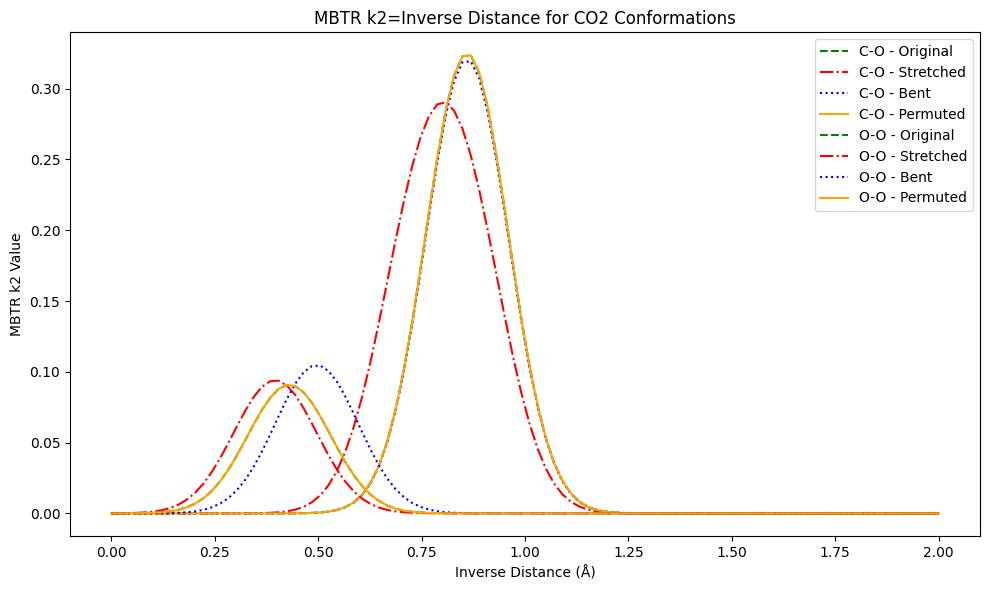

In [42]:
# Use inverse distance as a function
from dscribe.descriptors import MBTR
mbtr_k2 = MBTR(
    species=["C","O"],
    geometry={"function": "inverse_distance"},
    grid={"min": 0, "max": 2, "n": 100, "sigma": 0.1},
   weighting={"function": "exp", "scale": 0.5, "threshold": 1e-3},
    normalization="l2"
)
mbtr_co2_k2 = mbtr_k2.create(co2)
mbtr_co2_stretch_k2 = mbtr_k2.create(co2_stretch)
mbtr_co2_bent_k2 = mbtr_k2.create(co2_bent)
mbtr_co2_perm_k2 = mbtr_k2.create(co2_perm)
print(f"MBTR k2 descriptor shape: {mbtr_co2_k2.shape}")

n_elements = len(mbtr_k2.species)
x = np.linspace(0, 2, 100)
# Make one plot and show C-O and O-O distances

plt.figure(figsize=(10, 6))
for i in range(n_elements):
    for j in range(n_elements):
        if j>=i:
            i_species = mbtr_k2.species[i]
            j_species = mbtr_k2.species[j]
            # Check if C-O or O-O pair
            if (i_species == "C" and j_species == "O") or (i_species == "O" and j_species == "C"):
                label = "C-O"
            elif i_species == "O" and j_species == "O":
                label = "O-O"
            else:
                continue
            loc = mbtr_k2.get_location((i_species, j_species))
            plt.plot(x, mbtr_co2_k2[loc], label=f"{label} - Original", linestyle="--", color="green")
            plt.plot(x, mbtr_co2_stretch_k2[loc], label=f"{label} - Stretched", linestyle="-.", color="red")
            plt.plot(x, mbtr_co2_bent_k2[loc], label=f"{label} - Bent", linestyle=":", color="blue")
            plt.plot(x, mbtr_co2_perm_k2[loc], label=f"{label} - Permuted", linestyle="-", color="orange")
plt.xlabel("Inverse Distance (Å)")
plt.ylabel("MBTR k2 Value")
plt.title("MBTR k2=Inverse Distance for CO2 Conformations")
plt.legend()

plt.tight_layout()
plt.show()

## Smooth Overlap of Atomic Positions (SOAP)

Smooth Overlap of Atomic Positions (SOAP) is a descriptor which encodes regions of atomic geometries by using a local expansion of a gaussian smeared atomic density with orthonormal functions based on spherical harmonics and radial basis functions.

In [44]:
from dscribe.descriptors import SOAP

soap = SOAP(
    species=["C", "O"],
    r_cut=6.0,
    n_max=8, # Number of radial basis functions
    l_max=6, # Number of spherical harmonics
    sigma=0.5, # standard deviation of the gaussian smearing
    rbf = "gto", # Gaussian Type radial basis functions
    average="inner" # Averageing over sties before summing up magnetic quantum numbers
)

# Compute Soap Descriptors with nmax in [8, 10, 12]
soap_n8 = SOAP(
    species=["C", "O"],
    r_cut=6.0,
    n_max=8,
    l_max=6,
    sigma=0.5,
    rbf = "gto",
    average="inner"
)
soap_n10 = SOAP(
    species=["C", "O"],
    r_cut=6.0,
    n_max=10,
    l_max=6,
    sigma=0.5,
    rbf = "gto",
    average="inner"
)
soap_n12 = SOAP(
    species=["C", "O"],
    r_cut=6.0,
    n_max=12,
    l_max=6,
    sigma=0.5,
    rbf = "gto",
    average="inner"
)
soap_co2_n8 = soap_n8.create(co2)
soap_co2_stretch_n8 = soap_n8.create(co2_stretch)
soap_co2_bent_n8 = soap_n8.create(co2_bent)
soap_co2_perm_n8 = soap_n8.create(co2_perm)
print(f"SOAP descriptor with nmax=8 shape: {soap_co2_n8.shape}")
soap_co2_n10 = soap_n10.create(co2)
soap_co2_stretch_n10 = soap_n10.create(co2_stretch)
soap_co2_bent_n10 = soap_n10.create(co2_bent)
soap_co2_perm_n10 = soap_n10.create(co2_perm)
print(f"SOAP descriptor with nmax=10 shape: {soap_co2_n10.shape}")
soap_co2_n12 = soap_n12.create(co2)
soap_co2_stretch_n12 = soap_n12.create(co2_stretch)
soap_co2_bent_n12 = soap_n12.create(co2_bent)
soap_co2_perm_n12 = soap_n12.create(co2_perm)
print(f"SOAP descriptor with nmax=12 shape: {soap_co2_n12.shape}")

# Compute Similarity Metrics for SOAP descriptors with different nmax values
euc_stretch_n8, cos_stretch_n8, manh_stretch_n8 = compute_similarity_metrics(soap_co2_n8.flatten(), soap_co2_stretch_n8.flatten())
euc_bent_n8, cos_bent_n8, manh_bent_n8 = compute_similarity_metrics(soap_co2_n8.flatten(), soap_co2_bent_n8.flatten())
euc_perm_n8, cos_perm_n8, manh_perm_n8 = compute_similarity_metrics(soap_co2_n8.flatten(), soap_co2_perm_n8.flatten())
print("------------------------------------------------------")
print(f"SOAP Similarity Metrics with nmax=8 (Original vs Stretched): Euclidean={euc_stretch_n8:.4f}, Cosine Similarity={cos_stretch_n8:.4f}, Manhattan={manh_stretch_n8:.4f}")
print(f"SOAP Similarity Metrics with nmax=8 (Original vs Bent): Euclidean={euc_bent_n8:.4f}, Cosine Similarity={cos_bent_n8:.4f}, Manhattan={manh_bent_n8:.4f}")
print(f"SOAP Similarity Metrics with nmax=8 (Original vs Permuted): Euclidean={euc_perm_n8:.4f}, Cosine Similarity={cos_perm_n8:.4f}, Manhattan={manh_perm_n8:.4f}")
print("------------------------------------------------------")
euc_stretch_n10, cos_stretch_n10, manh_stretch_n10 = compute_similarity_metrics(soap_co2_n10.flatten(), soap_co2_stretch_n10.flatten())
euc_bent_n10, cos_bent_n10, manh_bent_n10 = compute_similarity_metrics(soap_co2_n10.flatten(), soap_co2_bent_n10.flatten())
euc_perm_n10, cos_perm_n10, manh_perm_n10 = compute_similarity_metrics(soap_co2_n10.flatten(), soap_co2_perm_n10.flatten())     
print("------------------------------------------------------")
print(f"SOAP Similarity Metrics with nmax=10 (Original vs Stretched): Euclidean={euc_stretch_n10:.4f}, Cosine Similarity={cos_stretch_n10:.4f}, Manhattan={manh_stretch_n10:.4f}")
print(f"SOAP Similarity Metrics with nmax=10 (Original vs Bent): Euclidean={euc_bent_n10:.4f}, Cosine Similarity={cos_bent_n10:.4f}, Manhattan={manh_bent_n10:.4f}")
print(f"SOAP Similarity Metrics with nmax=10 (Original vs Permuted): Euclidean={euc_perm_n10:.4f}, Cosine Similarity={cos_perm_n10:.4f}, Manhattan={manh_perm_n10:.4f}")
print("------------------------------------------------------")
euc_stretch_n12, cos_stretch_n12, manh_stretch_n12 = compute_similarity_metrics(soap_co2_n12.flatten(), soap_co2_stretch_n12.flatten())
euc_bent_n12, cos_bent_n12, manh_bent_n12 = compute_similarity_metrics(soap_co2_n12.flatten(), soap_co2_bent_n12.flatten())
euc_perm_n12, cos_perm_n12, manh_perm_n12 = compute_similarity_metrics(soap_co2_n12.flatten(), soap_co2_perm_n12.flatten())     
print("------------------------------------------------------")
print(f"SOAP Similarity Metrics with nmax=12 (Original vs Stretched): Euclidean={euc_stretch_n12:.4f}, Cosine Similarity={cos_stretch_n12:.4f}, Manhattan={manh_stretch_n12:.4f}")
print(f"SOAP Similarity Metrics with nmax=12 (Original vs Bent): Euclidean={euc_bent_n12:.4f}, Cosine Similarity={cos_bent_n12:.4f}, Manhattan={manh_bent_n12:.4f}")
print(f"SOAP Similarity Metrics with nmax=12 (Original vs Permuted): Euclidean={euc_perm_n12:.4f}, Cosine Similarity={cos_perm_n12:.4f}, Manhattan={manh_perm_n12:.4f}")
print("------------------------------------------------------")


SOAP descriptor with nmax=8 shape: (952,)
SOAP descriptor with nmax=10 shape: (1470,)
SOAP descriptor with nmax=12 shape: (2100,)
------------------------------------------------------
SOAP Similarity Metrics with nmax=8 (Original vs Stretched): Euclidean=0.5779, Cosine Similarity=0.0021, Manhattan=6.3091
SOAP Similarity Metrics with nmax=8 (Original vs Bent): Euclidean=0.6683, Cosine Similarity=0.0077, Manhattan=9.4322
SOAP Similarity Metrics with nmax=8 (Original vs Permuted): Euclidean=0.0000, Cosine Similarity=0.0000, Manhattan=0.0000
------------------------------------------------------
------------------------------------------------------
SOAP Similarity Metrics with nmax=10 (Original vs Stretched): Euclidean=0.5741, Cosine Similarity=0.0021, Manhattan=7.8281
SOAP Similarity Metrics with nmax=10 (Original vs Bent): Euclidean=0.6603, Cosine Similarity=0.0076, Manhattan=11.8356
SOAP Similarity Metrics with nmax=10 (Original vs Permuted): Euclidean=0.0000, Cosine Similarity=0.0000

One effect we clearly see here is that because of the rather high dimension of the SOAP descriptor similarty measures with the euclidean distance are not very meaningful anymore. 

In [45]:
# Create Soap descriptor with nmax=8 and lmax in [6, 8, 10]
soap_l6 = SOAP(
    species=["C", "O"],
    r_cut=6.0,
    n_max=8,
    l_max=6,
    sigma=0.5,
    rbf = "gto",
    average="inner"
)
soap_l8 = SOAP(
    species=["C", "O"],
    r_cut=6.0,
    n_max=8,
    l_max=8,
    sigma=0.5,
    rbf = "gto",
    average="inner"
)
soap_l10 = SOAP(
    species=["C", "O"],
    r_cut=6.0,
    n_max=8,
    l_max=10,
    sigma=0.5,
    rbf = "gto",
    average="inner"
)
soap_co2_l6 = soap_l6.create(co2)
soap_co2_stretch_l6 = soap_l6.create(co2_stretch)
soap_co2_bent_l6 = soap_l6.create(co2_bent)
soap_co2_perm_l6 = soap_l6.create(co2_perm)
print(f"SOAP descriptor with lmax=6 shape: {soap_co2_l6.shape}")
soap_co2_l8 = soap_l8.create(co2)
soap_co2_stretch_l8 = soap_l8.create(co2_stretch)
soap_co2_bent_l8 = soap_l8.create(co2_bent)
soap_co2_perm_l8 = soap_l8.create(co2_perm)
print(f"SOAP descriptor with lmax=8 shape: {soap_co2_l8.shape}")
soap_co2_l10 = soap_l10.create(co2)
soap_co2_stretch_l10 = soap_l10.create(co2_stretch)
soap_co2_bent_l10 = soap_l10.create(co2_bent)
soap_co2_perm_l10 = soap_l10.create(co2_perm)
print(f"SOAP descriptor with lmax=10 shape: {soap_co2_l10.shape}")  
# Compute Similarity Metrics for SOAP descriptors with different lmax values
euc_stretch_l6, cos_stretch_l6, manh_stretch_l6 = compute_similarity_metrics(soap_co2_l6.flatten(), soap_co2_stretch_l6.flatten())
euc_bent_l6, cos_bent_l6, manh_bent_l6 = compute_similarity_metrics(soap_co2_l6.flatten(), soap_co2_bent_l6.flatten())
euc_perm_l6, cos_perm_l6, manh_perm_l6 = compute_similarity_metrics(soap_co2_l6.flatten(), soap_co2_perm_l6.flatten())
print("------------------------------------------------------")
print(f"SOAP Similarity Metrics with lmax=6 (Original vs Stretched): Euclidean={euc_stretch_l6:.4f}, Cosine Similarity={cos_stretch_l6:.4f}, Manhattan={manh_stretch_l6:.4f}")
print(f"SOAP Similarity Metrics with lmax=6 (Original vs Bent): Euclidean={euc_bent_l6:.4f}, Cosine Similarity={cos_bent_l6:.4f}, Manhattan={manh_bent_l6:.4f}")
print(f"SOAP Similarity Metrics with lmax=6 (Original vs Permuted): Euclidean={euc_perm_l6:.4f}, Cosine Similarity={cos_perm_l6:.4f}, Manhattan={manh_perm_l6:.4f}")
print("------------------------------------------------------")
euc_stretch_l8, cos_stretch_l8, manh_stretch_l8 = compute_similarity_metrics(soap_co2_l8.flatten(), soap_co2_stretch_l8.flatten())
euc_bent_l8, cos_bent_l8, manh_bent_l8 = compute_similarity_metrics(soap_co2_l8.flatten(), soap_co2_bent_l8.flatten())
euc_perm_l8, cos_perm_l8, manh_perm_l8 = compute_similarity_metrics(soap_co2_l8.flatten(), soap_co2_perm_l8.flatten())     
print("------------------------------------------------------")
print(f"SOAP Similarity Metrics with lmax=8 (Original vs Stretched): Euclidean={euc_stretch_l8:.4f}, Cosine Similarity={cos_stretch_l8:.4f}, Manhattan={manh_stretch_l8:.4f}")  
print(f"SOAP Similarity Metrics with lmax=8 (Original vs Bent): Euclidean={euc_bent_l8:.4f}, Cosine Similarity={cos_bent_l8:.4f}, Manhattan={manh_bent_l8:.4f}")
print(f"SOAP Similarity Metrics with lmax=8 (Original vs Permuted): Euclidean={euc_perm_l8:.4f}, Cosine Similarity={cos_perm_l8:.4f}, Manhattan={manh_perm_l8:.4f}")
print("------------------------------------------------------")
euc_stretch_l10, cos_stretch_l10, manh_stretch_l10 = compute_similarity_metrics(soap_co2_l10.flatten(), soap_co2_stretch_l10.flatten()) 
euc_bent_l10, cos_bent_l10, manh_bent_l10 = compute_similarity_metrics(soap_co2_l10.flatten(), soap_co2_bent_l10.flatten())
euc_perm_l10, cos_perm_l10, manh_perm_l10 = compute_similarity_metrics(soap_co2_l10.flatten(), soap_co2_perm_l10.flatten())     
print("------------------------------------------------------")
print(f"SOAP Similarity Metrics with lmax=10 (Original vs Stretched): Euclidean={euc_stretch_l10:.4f}, Cosine Similarity={cos_stretch_l10:.4f}, Manhattan={manh_stretch_l10:.4f}")  
print(f"SOAP Similarity Metrics with lmax=10 (Original vs Bent): Euclidean={euc_bent_l10:.4f}, Cosine Similarity={cos_bent_l10:.4f}, Manhattan={manh_bent_l10:.4f}")
print(f"SOAP Similarity Metrics with lmax=10 (Original vs Permuted): Euclidean={euc_perm_l10:.4f}, Cosine Similarity={cos_perm_l10:.4f}, Manhattan={manh_perm_l10:.4f}")
print("------------------------------------------------------")


SOAP descriptor with lmax=6 shape: (952,)
SOAP descriptor with lmax=8 shape: (1224,)
SOAP descriptor with lmax=10 shape: (1496,)
------------------------------------------------------
SOAP Similarity Metrics with lmax=6 (Original vs Stretched): Euclidean=0.5779, Cosine Similarity=0.0021, Manhattan=6.3091
SOAP Similarity Metrics with lmax=6 (Original vs Bent): Euclidean=0.6683, Cosine Similarity=0.0077, Manhattan=9.4322
SOAP Similarity Metrics with lmax=6 (Original vs Permuted): Euclidean=0.0000, Cosine Similarity=0.0000, Manhattan=0.0000
------------------------------------------------------
------------------------------------------------------
SOAP Similarity Metrics with lmax=8 (Original vs Stretched): Euclidean=0.5780, Cosine Similarity=0.0021, Manhattan=6.3338
SOAP Similarity Metrics with lmax=8 (Original vs Bent): Euclidean=0.6684, Cosine Similarity=0.0077, Manhattan=9.4634
SOAP Similarity Metrics with lmax=8 (Original vs Permuted): Euclidean=0.0000, Cosine Similarity=0.0000, Man

# Metric Testing